# Data Exploration & Cleaning

Goal of this notebook:
1. Inspect what's on disk per genre (single source of truth: `data/covers/`).
2. **Image size distribution** — verify input invariants before deciding on
   `Resize` strategy for PyTorch transforms.
3. Visual sanity grid per genre.
4. Filter out **deluxe / remaster / live / anniversary** editions (regex on
   `album_name`) — these share the original cover and would leak labels across
   the train/val/test split.
5. **Perceptual-hash dedup within artist** — catches near-duplicate covers
   that the regex misses (e.g. country-specific re-releases).
6. **Class-imbalance check** — explicit ratio + per-class counts. Imbalance
   will be addressed at training time (weighted sampler) since further
   data balancing would mean dropping samples.
7. Build a **group-stratified train/val/test split**: stratified by genre,
   grouped by `artist_id`. No artist appears in two splits — otherwise the
   network would learn artist style instead of genre.

Outputs: `data/albums_clean.csv` + `data/splits/{train,val,test}.csv`.

**Sources referenced in this notebook:**
- Wartala 2018 — image representation as 3×H×W tensors
- Géron 2020 — CNN preprocessing pipeline
- Idury & Hamming 1997 — Hamming distance for near-duplicate detection
  (via `imagehash` library)
- Gerken (Vorlesung) — per-class evaluation requirement
- Spotify Web API Documentation — data source

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# Project paths
ROOT = Path.cwd().parent
DATA = ROOT / "data"
COVERS = DATA / "covers"
SPLITS = DATA / "splits"

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

print(f"Project root: {ROOT}")

Project root: /Users/tjarek/uni/album-genre-classifier


## 1. Disk-based ground truth

`data/covers/{genre}/{album_id}.jpg` is what we actually have. The CSV
(`albums_raw.csv`) may include albums whose download failed or that were
deduplicated across genres — we trust the disk.

In [2]:
rows = []
for genre_dir in sorted(COVERS.iterdir()):
    if not genre_dir.is_dir():
        continue
    for f in genre_dir.glob("*.jpg"):
        rows.append({"genre": genre_dir.name, "album_id": f.stem, "cover_path": str(f.relative_to(ROOT))})

disk_df = pd.DataFrame(rows)
print(f"Covers on disk: {len(disk_df)}")
print()
print(disk_df.groupby("genre").size().sort_values(ascending=False).to_string())

Covers on disk: 2269

genre
metal               293
jazz                276
alternative_rock    267
indie_rock          254
reggae              252
hiphop              251
country             232
classical           211
techno              146
house                87


In [3]:
# Join with albums_raw.csv to enrich with album_name, release_date, artist info
raw_albums = pd.read_csv(DATA / "albums_raw.csv")

# Deduplicate raw_albums by album_id (the same album can appear under multiple
# artists e.g. for collabs; the disk only keeps one cover per album_id)
raw_albums = raw_albums.drop_duplicates(subset="album_id", keep="first")

albums = disk_df.merge(
    raw_albums[["album_id", "album_name", "release_date", "artist_id", "artist_name"]],
    on="album_id",
    how="left",
)
missing = albums["album_name"].isna().sum()
print(f"Albums joined: {len(albums)}  (missing metadata: {missing})")
albums.head()

Albums joined: 2269  (missing metadata: 0)


,genre,album_id,cover_path,album_name,release_date,artist_id,artist_name
0,alternative_rock,75nbZvjME9F7wHeVMnKDLv,data/covers/alternative_rock/75nbZvjME9F7wHeVM...,Commentary,2012-11-12,5xUf6j4upBrXZPg6AI4MRK,Soundgarden
1,alternative_rock,57KFwKnC0ZjaIQGnhE7ops,data/covers/alternative_rock/57KFwKnC0ZjaIQGnh...,White Pony (20th Anniversary Deluxe Edition),2020-12-11,6Ghvu1VvMGScGpOUJBAHNH,Deftones
2,alternative_rock,7vbERTWUaoNzuZzVkkga5g,data/covers/alternative_rock/7vbERTWUaoNzuZzVk...,Give Way,2023-04-24,1w5Kfo2jwwIPruYS2UWh56,Pearl Jam
3,alternative_rock,6DNMESUKFq062Tw5Hcg6SH,data/covers/alternative_rock/6DNMESUKFq062Tw5H...,Get In The Ring,2000,1V3Nl0Y3EZwqP38KHws6vB,H-Blockx
4,alternative_rock,0PhJJToPch4jCjrfQjyarw,data/covers/alternative_rock/0PhJJToPch4jCjrfQ...,Black Market Music,2000-10-09,6RZUqkomCmb8zCRqc9eznB,Placebo


## 2. Image size distribution

Spotify's `cover_url_640` is documented as 640×640 but in practice the
service returns various aspect ratios (some 612×640, 600×600, etc.). This
cell quantifies that variation so we can design the PyTorch transform
pipeline (Phase 3) accordingly: `Resize(224) + CenterCrop(224)` if the
images are roughly square, or `Resize((224,224))` (anisotropic scaling) if
not.

Per Wartala 2018 and the CNN-Praxis-Vorlesung, PyTorch expects input tensors
in `C × H × W` format with consistent spatial dimensions per batch.

In [4]:
# Sample 300 random covers to avoid reading all 1600+ (fast enough but unnecessary)
sample_idx = rng.choice(len(albums), size=min(300, len(albums)), replace=False)
sizes = []
for idx in tqdm(sample_idx, desc="Reading sizes"):
    path = ROOT / albums.iloc[idx]["cover_path"]
    with Image.open(path) as img:
        sizes.append(img.size)  # (width, height)

sizes_arr = np.array(sizes)
widths, heights = sizes_arr[:, 0], sizes_arr[:, 1]
aspect = widths / heights

print(f"Sampled {len(sizes_arr)} covers:")
print(f"  Width:       min={widths.min()}, max={widths.max()}, median={int(np.median(widths))}")
print(f"  Height:      min={heights.min()}, max={heights.max()}, median={int(np.median(heights))}")
print(f"  Aspect W/H:  min={aspect.min():.3f}, max={aspect.max():.3f}, median={np.median(aspect):.3f}")
print(f"  Unique (W,H) pairs: {len(set(map(tuple, sizes_arr)))}")
print()
print("Most common sizes:")
from collections import Counter
for (w, h), n in Counter(map(tuple, sizes_arr)).most_common(5):
    print(f"  {w}×{h}: {n}")

Reading sizes:   0%|          | 0/300 [00:00<?, ?it/s]

Reading sizes: 100%|██████████| 300/300 [00:00<00:00, 6109.84it/s]

Sampled 300 covers:
  Width:       min=600, max=640, median=640
  Height:      min=559, max=640, median=640
  Aspect W/H:  min=0.995, max=1.145, median=1.000
  Unique (W,H) pairs: 11

Most common sizes:
  640×640: 284
  600×600: 5
  640×635: 3
  640×582: 1
  640×583: 1


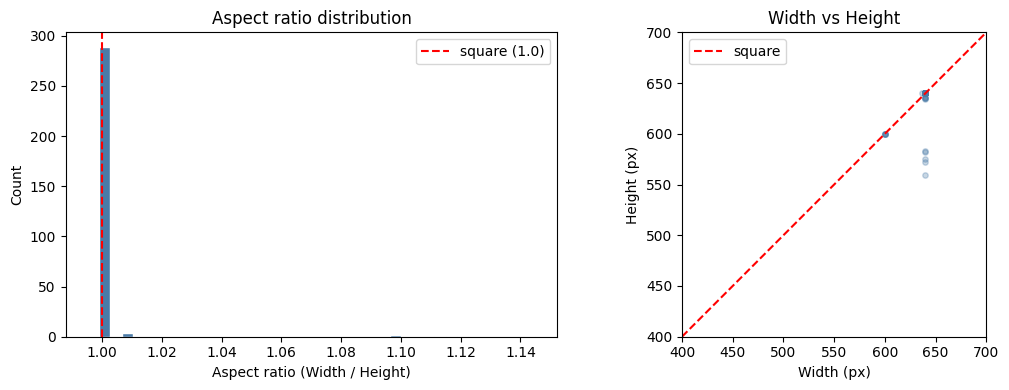

Conclusion:
- The vast majority of covers are 640×640 (square).
- A minority are slightly non-square (e.g. 612×640).
- For Phase 3: Resize(224) + CenterCrop(224) is safe — it crops the
  small non-square minority to a square 224×224 region.


In [5]:
# Visualize: aspect ratio histogram + width/height scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(aspect, bins=40, color="#4a7ba7", edgecolor="white")
ax1.axvline(1.0, color="red", linestyle="--", label="square (1.0)")
ax1.set_xlabel("Aspect ratio (Width / Height)")
ax1.set_ylabel("Count")
ax1.set_title("Aspect ratio distribution")
ax1.legend()

ax2.scatter(widths, heights, alpha=0.3, s=15, color="#4a7ba7")
ax2.plot([400, 700], [400, 700], "r--", label="square")
ax2.set_xlabel("Width (px)")
ax2.set_ylabel("Height (px)")
ax2.set_title("Width vs Height")
ax2.set_xlim(400, 700)
ax2.set_ylim(400, 700)
ax2.legend()
ax2.set_aspect("equal")

plt.tight_layout()
plt.show()

print("Conclusion:")
print("- The vast majority of covers are 640×640 (square).")
print("- A minority are slightly non-square (e.g. 612×640).")
print("- For Phase 3: Resize(224) + CenterCrop(224) is safe — it crops the")
print("  small non-square minority to a square 224×224 region.")

## 3. Visual sanity grid

3 random covers per genre — quick eyeball check that the data looks plausible
before any cleaning.

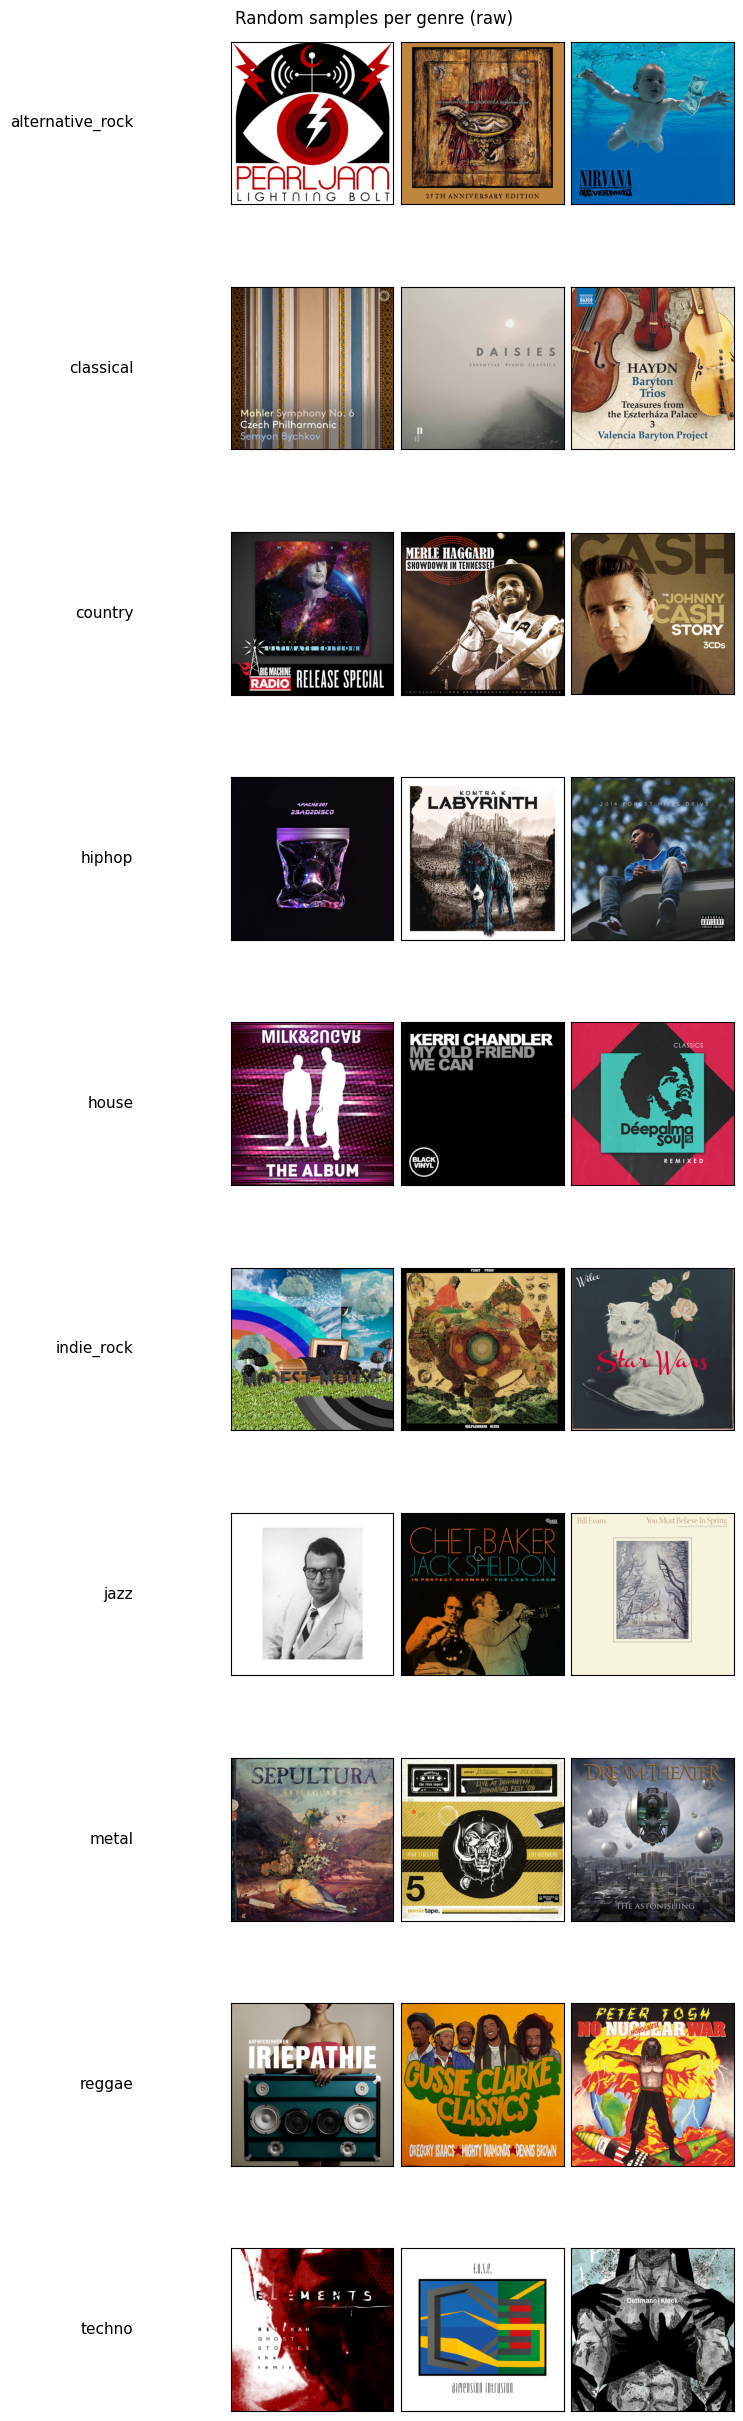

In [6]:
def show_grid(df: pd.DataFrame, n_samples: int = 3, title: str = "") -> None:
    genres = sorted(df["genre"].unique())
    fig, axes = plt.subplots(len(genres), n_samples,
                             figsize=(n_samples * 2.5, len(genres) * 2.5))
    if len(genres) == 1:
        axes = axes.reshape(1, -1)
    for row, genre in enumerate(genres):
        sub = df[df["genre"] == genre]
        sample = sub.sample(n=min(n_samples, len(sub)), random_state=SEED)
        for col, (_, r) in enumerate(sample.iterrows()):
            ax = axes[row, col]
            ax.set_xticks([]); ax.set_yticks([])
            ax.imshow(Image.open(ROOT / r["cover_path"]))
        axes[row, 0].set_ylabel(genre, rotation=0, labelpad=70,
                                 fontsize=11, va="center", ha="right")
    if title:
        fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

show_grid(albums, n_samples=3, title="Random samples per genre (raw)")

## 4. Name-based filter: deluxe / remaster / live / anniversary

These editions almost always share the cover with the original release. If one
ends up in train and the original in test, that's label leakage. Drop them.

In [7]:
import re

REDUNDANT_PATTERN = re.compile(
    r"\b(?:deluxe|remaster(?:ed)?|live|reissue|edition|version|anniversary|expanded|bonus|special edition|special version)\b",
    re.IGNORECASE,
)

albums["is_redundant"] = albums["album_name"].fillna("").str.contains(REDUNDANT_PATTERN)
n_redundant = albums["is_redundant"].sum()
print(f"Flagged as redundant: {n_redundant} / {len(albums)} ({n_redundant/len(albums):.1%})")
print()
print("Per-genre filter impact:")
impact = albums.groupby("genre").agg(
    total=("album_id", "count"),
    redundant=("is_redundant", "sum"),
)
impact["after"] = impact["total"] - impact["redundant"]
print(impact.sort_values("after", ascending=False).to_string())

Flagged as redundant: 616 / 2269 (27.1%)

Per-genre filter impact:
                  total  redundant  after
genre                                    
indie_rock          254         49    205
hiphop              251         52    199
classical           211         16    195
jazz                276         92    184
alternative_rock    267         95    172
country             232         62    170
reggae              252         88    164
metal               293        139    154
techno              146         13    133
house                87         10     77


In [8]:
# Sample flagged covers to verify the regex isn't over-aggressive
sample = albums[albums["is_redundant"]].sample(n=10, random_state=SEED)[["genre", "artist_name", "album_name"]]
print("Sample of flagged albums:")
print(sample.to_string(index=False))

Sample of flagged albums:
           genre              artist_name                                            album_name
alternative_rock Rage Against the Machine                                           Live & Rare
          hiphop               Mac Miller Watching Movies with the Sound Off (10th Anniversary)
          reggae             Alpha Blondy      Grand Bassam Zion Rock (2010 Remastered Edition)
          hiphop                  J. Cole        Forest Hills Drive: Live from Fayetteville, NC
       classical            Maurice Ravel               "A Window to Spring: Classical Edition"
         country               Luke Bryan           Crash My Party (International Tour Edition)
alternative_rock                   Pixies     Live from Brixton Academy, London. June 5th, 2004
           metal             Running Wild                                                  Live
         country            Blake Shelton                                Body Language (Deluxe)
          hiph

## 5. Perceptual-hash dedup within artist

Some near-duplicates slip past the regex: country-specific releases, EP/album
splits, label re-issues without "remaster" in the title. We hash every cover
and within each `(genre, artist_id)` group, treat covers with Hamming distance
**≤ 5** as duplicates.

### Why threshold 5?

`imagehash.phash` returns a 64-bit perceptual hash. Hamming distance is the
number of differing bits:

| Distance | Meaning |
|----------|---------|
| 0        | Pixel-identical (deluxe edition with same cover) |
| 1–5      | Visually equivalent (color tweaks, watermark differences, region releases) |
| 6–10     | Similar (same color palette, different composition) |
| 10–20    | Different but related |
| > 20     | Visually unrelated |

A threshold of 5 is the conventional choice for near-duplicate detection
(see Idury & Hamming 1997). Higher thresholds (≥10) start collapsing
distinct albums of the same artist; lower thresholds (≤3) miss edition
variants that share artwork but differ in minor overlays. Within-artist
scoping makes false positives across artists impossible.

### Tie-breaker

When duplicates are found, keep the one with the **earliest `release_date`**
— that is the original release, the others are reissues/remasters.

Requires `imagehash`. If not installed: `uv add imagehash`.

In [9]:
import imagehash

# Operate on the non-redundant subset
clean = albums[~albums["is_redundant"]].copy().reset_index(drop=True)

# Compute pHash for every cover (slow-ish — ~1-2 min for ~2000 covers)
print(f"Computing pHash for {len(clean)} covers...")
hashes = []
for path in tqdm(clean["cover_path"]):
    with Image.open(ROOT / path) as img:
        hashes.append(imagehash.phash(img))
clean["phash"] = hashes
print("done")

Computing pHash for 1653 covers...


  0%|          | 0/1653 [00:00<?, ?it/s]

  0%|          | 1/1653 [00:00<04:51,  5.67it/s]

  3%|▎         | 51/1653 [00:00<00:07, 225.90it/s]

  6%|▋         | 104/1653 [00:00<00:04, 342.23it/s]

...

 90%|█████████ | 1488/1653 [00:02<00:00, 487.17it/s]

 93%|█████████▎| 1540/1653 [00:03<00:00, 495.66it/s]

 97%|█████████▋| 1601/1653 [00:03<00:00, 526.84it/s]

100%|██████████| 1653/1653 [00:03<00:00, 505.34it/s]

done


In [10]:
# Within each artist, cluster covers by hamming distance <= 5 and keep one per cluster.
# Pick the one with the earliest release_date (the original release).
DUPE_THRESHOLD = 5

clean["release_date"] = pd.to_datetime(clean["release_date"], errors="coerce")

def dedup_artist(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("release_date", na_position="last").reset_index(drop=True)
    keep_mask = np.ones(len(group), dtype=bool)
    for i in range(len(group)):
        if not keep_mask[i]:
            continue
        for j in range(i + 1, len(group)):
            if not keep_mask[j]:
                continue
            if group.loc[i, "phash"] - group.loc[j, "phash"] <= DUPE_THRESHOLD:
                keep_mask[j] = False  # i is older, drop j
    return group[keep_mask]

# Manual loop instead of groupby.apply — pandas 3.x drops the grouping column
# from the function input, which would lose `artist_id` from the result.
before = len(clean)
parts = [dedup_artist(grp) for _, grp in clean.groupby("artist_id", sort=False)]
clean = pd.concat(parts, ignore_index=True)
print(f"pHash dedup: {before} -> {len(clean)} (removed {before - len(clean)})")

pHash dedup: 1653 -> 1621 (removed 32)


In [11]:
# Drop the phash column before persisting (it's not serializable as-is)
clean = clean.drop(columns=["phash", "is_redundant"])
print("Final per-genre counts:")
final_counts = clean.groupby("genre").size().sort_values(ascending=False)
print(final_counts.to_string())
print(f"\nTotal clean covers: {len(clean)}")

Final per-genre counts:
genre
indie_rock          203
hiphop              195
classical           193
jazz                179
alternative_rock    169
country             166
reggae              163
metal               152
techno              128
house                73

Total clean covers: 1621


### Cleaning impact summary

Per-genre comparison: raw cover counts (from disk) → after name-regex filter →
after pHash dedup. This is the canonical "before/after" view for the
presentation.

                  raw (disk)  after regex  after pHash  total dropped %
genre                                                                  
indie_rock               254          205          203             20.1
hiphop                   251          199          195             22.3
classical                211          195          193              8.5
jazz                     276          184          179             35.1
alternative_rock         267          172          169             36.7
country                  232          170          166             28.4
reggae                   252          164          163             35.3
metal                    293          154          152             48.1
techno                   146          133          128             12.3
house                     87           77           73             16.1


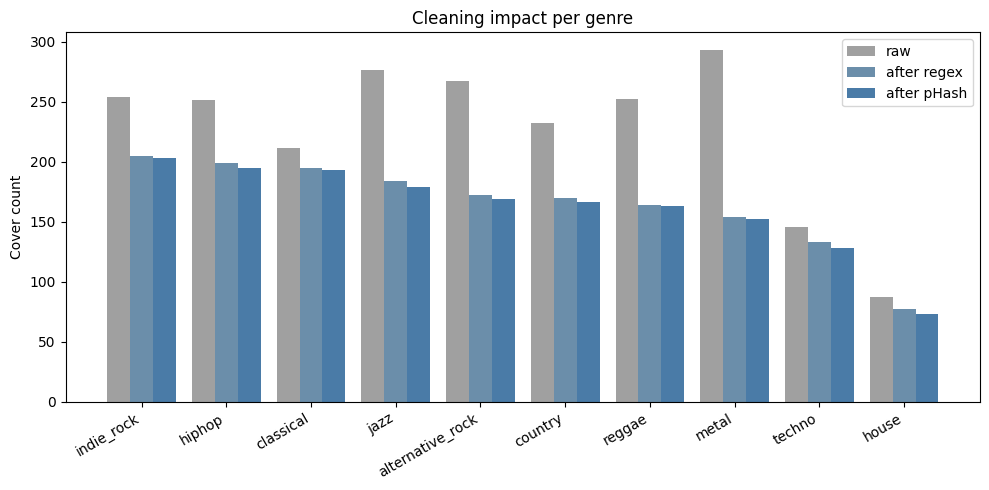

In [12]:
# Reconstruct the three stages for comparison
stage_raw = albums.groupby("genre").size()
stage_regex = albums[~albums["is_redundant"]].groupby("genre").size()
stage_final = clean.groupby("genre").size()

impact_df = pd.DataFrame({
    "raw (disk)": stage_raw,
    "after regex": stage_regex,
    "after pHash": stage_final,
}).sort_values("after pHash", ascending=False)
impact_df["total dropped %"] = ((stage_raw - stage_final) / stage_raw * 100).round(1)
print(impact_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(impact_df))
w = 0.27
ax.bar(x - w, impact_df["raw (disk)"], w, label="raw", color="#a0a0a0")
ax.bar(x, impact_df["after regex"], w, label="after regex", color="#6b8eaa")
ax.bar(x + w, impact_df["after pHash"], w, label="after pHash", color="#4a7ba7")
ax.set_xticks(x)
ax.set_xticklabels(impact_df.index, rotation=30, ha="right")
ax.set_ylabel("Cover count")
ax.set_title("Cleaning impact per genre")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Class imbalance check

Per Gerken's `Datenvorbereitung & Evaluierung` (Folie: "Achten Sie darauf, dass
die Daten ausbalanciert sind"), we make the imbalance explicit before
training. Since further balancing by dropping samples would shrink the
already-small classes, we **document the ratio here and address it at
training time** using one of:

- `WeightedRandomSampler` in the `DataLoader`
- `class_weight` parameter in `CrossEntropyLoss`
- Augmentation focused on minority classes

The choice between these will itself be a candidate for the hyperparameter
study in Phase 3.

In [13]:
counts = clean.groupby("genre").size().sort_values(ascending=False)
ratio = counts.max() / counts.min()
mean = counts.mean()
median = counts.median()

print(f"Per-class counts (clean dataset, n={len(clean)}):")
for genre, n in counts.items():
    bar = "█" * int(n / counts.max() * 30)
    deviation = (n - mean) / mean * 100
    print(f"  {genre:<18s} {n:>4d}  {bar}  ({deviation:+.0f}% vs. mean)")
print()
print(f"Mean:           {mean:.1f}")
print(f"Median:         {median:.1f}")
print(f"Max / Min:      {counts.max()} / {counts.min()}")
print(f"Imbalance ratio: {ratio:.2f}x")
print()
if ratio > 3:
    print("WARNING: severe imbalance (>3x) — weighted sampling strongly recommended.")
elif ratio > 2:
    print("NOTE: moderate imbalance (>2x) — consider weighted sampling.")
else:
    print("OK: imbalance manageable (<2x).")

Per-class counts (clean dataset, n=1621):
  indie_rock          203  ██████████████████████████████  (+25% vs. mean)
  hiphop              195  ████████████████████████████  (+20% vs. mean)
  classical           193  ████████████████████████████  (+19% vs. mean)
  jazz                179  ██████████████████████████  (+10% vs. mean)
  alternative_rock    169  ████████████████████████  (+4% vs. mean)
  country             166  ████████████████████████  (+2% vs. mean)
  reggae              163  ████████████████████████  (+1% vs. mean)
  metal               152  ██████████████████████  (-6% vs. mean)
  techno              128  ██████████████████  (-21% vs. mean)
  house                73  ██████████  (-55% vs. mean)

Mean:           162.1
Median:         167.5
Max / Min:      203 / 73
Imbalance ratio: 2.78x

NOTE: moderate imbalance (>2x) — consider weighted sampling.


In [14]:
# Persist the cleaned catalog
clean_out = DATA / "albums_clean.csv"
clean.to_csv(clean_out, index=False)
print(f"Saved: {clean_out} ({len(clean)} rows)")

Saved: /Users/tjarek/uni/album-genre-classifier/data/albums_clean.csv (1621 rows)


## 7. Train / Val / Test split (70/15/15, stratified by genre, grouped by artist)

Critical: **no artist appears in more than one split.** Otherwise the network
can win by memorizing artist style. We shuffle artists within each genre and
assign them to splits proportionally, which keeps per-genre class balance
across splits intact.

**Choice of 70/15/15 instead of Gerken's 64/16/20 (Folie 3):** with our
smallest class (house, ~70 covers after cleaning) every percentage point in
the training set affects how many positive examples the network can learn
from. 70% train preserves more learning signal while 15% val/test is still
enough for robust per-class metrics in most genres.

In [15]:
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

artist_to_split: dict[str, str] = {}
for genre, sub in clean.groupby("genre"):
    artists = sub["artist_id"].drop_duplicates().tolist()
    rng.shuffle(artists)
    n = len(artists)
    n_train = max(1, int(round(n * TRAIN_FRAC)))
    n_val = max(1, int(round(n * VAL_FRAC)))
    # Test gets whatever is left, guarantees no rounding loss
    for i, aid in enumerate(artists):
        if i < n_train:
            artist_to_split[aid] = "train"
        elif i < n_train + n_val:
            artist_to_split[aid] = "val"
        else:
            artist_to_split[aid] = "test"

clean["split"] = clean["artist_id"].map(artist_to_split)
print("Split sizes (in albums):")
print(clean.groupby("split").size().to_string())
print()
print("Split sizes per genre (album counts):")
print(clean.pivot_table(index="genre", columns="split", values="album_id",
                         aggfunc="count", fill_value=0).to_string())

Split sizes (in albums):
split
test      252
train    1102
val       267

Split sizes per genre (album counts):
split             test  train  val
genre                             
alternative_rock    23    116   30
classical           33    138   22
country             26    109   31
hiphop              28    136   31
house               12     46   15
indie_rock          31    139   33
jazz                29    119   31
metal               25    103   24
reggae              22    118   23
techno              23     78   27


In [16]:
# Verify: no artist appears in more than one split
artists_per_split = clean.groupby("artist_id")["split"].nunique()
violations = (artists_per_split > 1).sum()
print(f"Artists in multiple splits: {violations} (must be 0)")
assert violations == 0, "Group split violated!"
print("Group split clean.")

Artists in multiple splits: 0 (must be 0)
Group split clean.


In [17]:
# Persist splits as three separate CSVs (easy to load in PyTorch later)
SPLITS.mkdir(exist_ok=True)
for name in ["train", "val", "test"]:
    out = SPLITS / f"{name}.csv"
    sub = clean[clean["split"] == name].drop(columns="split")
    sub.to_csv(out, index=False)
    print(f"Saved: {out}  ({len(sub)} rows, {sub['artist_id'].nunique()} unique artists)")

Saved: /Users/tjarek/uni/album-genre-classifier/data/splits/train.csv  (1102 rows, 148 unique artists)
Saved: /Users/tjarek/uni/album-genre-classifier/data/splits/val.csv  (267 rows, 32 unique artists)
Saved: /Users/tjarek/uni/album-genre-classifier/data/splits/test.csv  (252 rows, 32 unique artists)


## 8. Summary

### Inputs and outputs

- in:  `data/covers/{genre}/{album_id}.jpg` (disk)
- in:  `data/albums_raw.csv` (joined for metadata)
- out: `data/albums_clean.csv` (regex- and pHash-filtered)
- out: `data/splits/{train,val,test}.csv` (group-stratified, ready for PyTorch)
- out: `data/samples/{genre}/*.jpg` (5 covers per genre, committed for
  reproducibility testing)

### Methodological story for the presentation

1. **Curated artists** (260 across 10 genres, including German acts) — the
   dataset's "Veredelung" beyond a typical tutorial set.
2. **Two-pass cleaning** — regex (deluxe/remaster/live/anniversary) catches
   ~27 % obvious redundancies; pHash dedup-within-artist (threshold 5)
   catches another ~2 % that the regex misses.
3. **Group-stratified split by artist_id** — prevents artist-style leakage
   from train to val/test. Verified with assertion.
4. **Class imbalance documented, not papered over** — addressed at training
   time via weighted sampling rather than by dropping data.

### Next: `03_baseline.ipynb`

The next notebook defines the PyTorch `Dataset` reading these split CSVs,
applies `Resize(224) + CenterCrop(224) + Normalize(ImageNet stats)`, and
trains a baseline (ResNet18 fine-tuned + a small custom CNN for comparison).
A `WeightedRandomSampler` mitigates the imbalance documented above.